# Scaffold Split — Chemistry-Aware Evaluation

**The problem with random splits:** in ESOL, a random 80/20 split lets molecules
that share the same molecular core end up in both train and test. The model then
"generalizes" by pattern-matching against very similar molecules it has already seen.
That inflates the reported test score compared to real-world deployment, where
you want to predict solubility of *new* chemistry.

**Scaffold split fixes this.** For each molecule, extract its
**Bemis-Murcko scaffold** (the ring system + linkers, stripping off side chains).
Then split so every molecule sharing a scaffold ends up in either train or test
— never both. This forces the model to generalize to *unseen chemistry classes*,
which is what matters in drug discovery.

**Plan:**
1. Compute the Murcko scaffold for every molecule
2. Analyze scaffold distribution
3. Build a scaffold-aware train/test split
4. Retrain XGBoost + linear regression on 7 features (including logP) under the new split
5. Compare RMSE random-split vs scaffold-split — expect the scaffold-split number to be **worse**, and that's the honest number.

In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from rdkit import Chem
from rdkit.Chem import Crippen
from rdkit.Chem.Scaffolds import MurckoScaffold

from sklearn.model_selection import train_test_split, KFold, GridSearchCV
from sklearn.linear_model import LinearRegression
from sklearn.metrics import mean_absolute_error, r2_score, root_mean_squared_error
from xgboost import XGBRegressor

RANDOM_STATE = 42

## 1. Load the data and recompute the 7-feature matrix

We reproduce the 7-feature X (6 CSV + logP) from `Feature_engineering.ipynb`
so this notebook stands alone.

In [2]:
df = pd.read_csv("delaney-processed.csv")

Target = 'measured log solubility in mols per litre'
original_features = [
    'Minimum Degree', 'Molecular Weight', 'Number of H-Bond Donors',
    'Number of Rings', 'Number of Rotatable Bonds', 'Polar Surface Area'
]

# Recompute logP for every molecule
def compute_logp(smi):
    mol = Chem.MolFromSmiles(smi)
    return np.nan if mol is None else Crippen.MolLogP(mol)

df["logP"] = df["smiles"].apply(compute_logp)

new_features = original_features + ["logP"]
X = df[new_features]
y = df[Target]

print("Molecules:", len(df))
print("Features :", len(new_features))

Molecules: 1128
Features : 7


## 2. Compute Bemis-Murcko scaffolds

A **Bemis-Murcko scaffold** is what you get by stripping every atom that isn't
in a ring or on a linker between rings. It's the "carbon skeleton" of the
molecule. Two molecules with the same scaffold share the same core chemistry
even if their side chains differ wildly.

RDKit gives us a one-liner:
```python
MurckoScaffold.MurckoScaffoldSmiles(smiles=smi, includeChirality=False)
```

**Examples we'll verify below:**
- Aspirin → benzene ring scaffold
- Ibuprofen → benzene ring scaffold (same core, different substituents)
- Ethanol → empty scaffold (no rings at all)

In [3]:
def get_scaffold(smiles):
    """Return the Bemis-Murcko scaffold SMILES for a molecule."""
    try:
        return MurckoScaffold.MurckoScaffoldSmiles(smiles=smiles, includeChirality=False)
    except Exception:
        return ""

df["scaffold"] = df["smiles"].apply(get_scaffold)

# Sanity check on well-known molecules from our dataset
demo = [("CCO", "ethanol"), ("c1ccccc1", "benzene"), ("Cc1ccccc1", "toluene")]
for smi, name in demo:
    print(f"{name:<15s} SMILES={smi:<20s} scaffold={get_scaffold(smi)!r}")

ethanol         SMILES=CCO                  scaffold=''
benzene         SMILES=c1ccccc1             scaffold='c1ccccc1'
toluene         SMILES=Cc1ccccc1            scaffold='c1ccccc1'


## 3. Scaffold distribution

How many unique scaffolds does the dataset have? How lumpy is the distribution?

In [4]:
scaffold_counts = df["scaffold"].value_counts()

print(f"Total molecules       : {len(df)}")
print(f"Unique scaffolds      : {len(scaffold_counts)}")
print(f"Singleton scaffolds   : {(scaffold_counts == 1).sum()}  "
      f"({100 * (scaffold_counts == 1).sum() / len(scaffold_counts):.1f}% of scaffolds)")
print(f"Empty scaffold count  : {scaffold_counts.get('', 0)}  (acyclic molecules)")
print(f"Largest scaffold size : {scaffold_counts.iloc[0]} molecules  "
      f"(scaffold = {scaffold_counts.index[0]!r})")

print("\nTop 10 scaffolds by molecule count:")
print(scaffold_counts.head(10))

Total molecules       : 1128
Unique scaffolds      : 269
Singleton scaffolds   : 194  (72.1% of scaffolds)
Empty scaffold count  : 317  (acyclic molecules)
Largest scaffold size : 317 molecules  (scaffold = '')

Top 10 scaffolds by molecule count:
scaffold
                                317
c1ccccc1                        254
c1ccc(-c2ccccc2)cc1              39
c1ccc2ccccc2c1                   22
O=C1CC(=O)NC(=O)N1               21
O=C1C=C2CCC3C4CCCC4CCC3C2CC1     17
c1ncncn1                         16
c1ccncc1                         14
c1ccc(Cc2ccccc2)cc1              12
C1CCCCC1                         10
Name: count, dtype: int64


**How to read that output:**
- If most scaffolds are singletons, a scaffold split is very challenging — most
  test molecules have zero-shot chemistry.
- If a handful of scaffolds dominate, forcing them into train leaves an easier
  test set but a much smaller train set. There's a tradeoff.

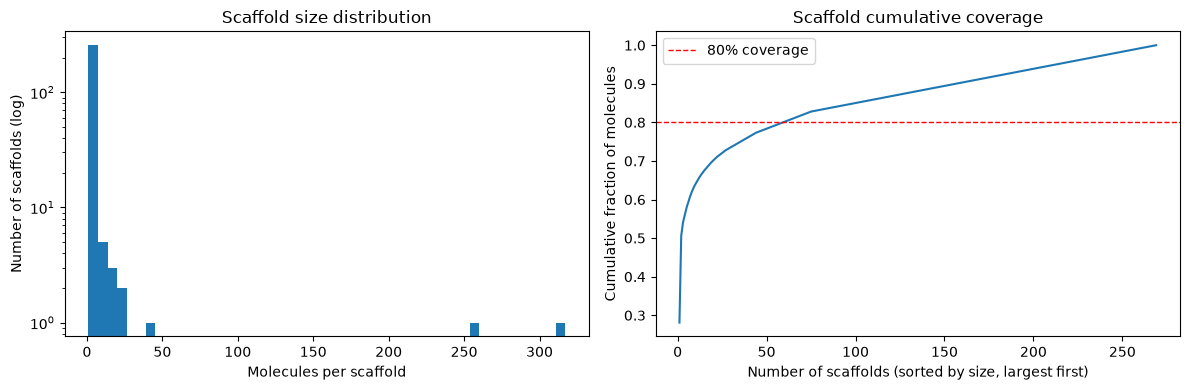

In [5]:
fig, axes = plt.subplots(1, 2, figsize=(12, 4))

# Distribution of scaffold sizes (log-scale)
axes[0].hist(scaffold_counts.values, bins=50, log=True)
axes[0].set_xlabel("Molecules per scaffold")
axes[0].set_ylabel("Number of scaffolds (log)")
axes[0].set_title("Scaffold size distribution")

# Cumulative coverage: how many scaffolds do we need to cover N% of molecules?
sorted_sizes = np.sort(scaffold_counts.values)[::-1]
cumulative = np.cumsum(sorted_sizes) / sorted_sizes.sum()
axes[1].plot(np.arange(1, len(cumulative) + 1), cumulative)
axes[1].axhline(0.8, color="r", linestyle="--", linewidth=1, label="80% coverage")
axes[1].set_xlabel("Number of scaffolds (sorted by size, largest first)")
axes[1].set_ylabel("Cumulative fraction of molecules")
axes[1].set_title("Scaffold cumulative coverage")
axes[1].legend()

plt.tight_layout()
plt.savefig("figures/sc_scaffold_distribution.pdf", bbox_inches="tight")
plt.show()

## 4. Scaffold-aware train/test split

**Standard approach** (from Bemis-Murcko-based benchmarking, used by MoleculeNet
and DeepChem):

1. Group molecules by scaffold.
2. Sort scaffold groups by size, **largest first**.
3. Fill the train set with molecules from those groups until train has ~80% of
   the data.
4. Everything left over goes to test.

**Why largest-first?** Puts common chemistry in train (where the model needs to
learn general patterns) and pushes rare/singleton scaffolds into test (where the
model has to generalize to unfamiliar cores). This is the harder, more realistic
evaluation.

In [6]:
def scaffold_split(df, test_frac=0.20):
    """
    Split dataframe by scaffold. Returns (train_idx, test_idx).
    Molecules sharing a scaffold are guaranteed to end up in the same split.
    Largest scaffolds go into train first.
    """
    scaffold_groups = df.groupby("scaffold").indices  # dict: scaffold_smiles -> array of row indices
    # Sort scaffold groups by size, largest first
    groups_sorted = sorted(scaffold_groups.values(), key=len, reverse=True)

    n_total = len(df)
    n_train_target = int(round(n_total * (1 - test_frac)))

    train_idx, test_idx = [], []
    for group in groups_sorted:
        if len(train_idx) + len(group) <= n_train_target:
            train_idx.extend(group)
        else:
            test_idx.extend(group)
    return np.array(train_idx), np.array(test_idx)

train_idx, test_idx = scaffold_split(df, test_frac=0.20)

# Verify: no scaffold should appear in both splits
train_scaffolds = set(df.iloc[train_idx]["scaffold"])
test_scaffolds  = set(df.iloc[test_idx]["scaffold"])
overlap = train_scaffolds & test_scaffolds
print(f"Train molecules: {len(train_idx)}  ({100 * len(train_idx) / len(df):.1f}%)")
print(f"Test  molecules: {len(test_idx)}   ({100 * len(test_idx)  / len(df):.1f}%)")
print(f"Train scaffolds: {len(train_scaffolds)}")
print(f"Test  scaffolds: {len(test_scaffolds)}")
print(f"Scaffold overlap: {len(overlap)}  (should be 0)")

Train molecules: 902  (80.0%)
Test  molecules: 226   (20.0%)
Train scaffolds: 59
Test  scaffolds: 210
Scaffold overlap: 0  (should be 0)


### The train and test sets are chemically distinct

Under scaffold split, the test-set molecules have core structures the training
data has never seen. Under random split, that's not true — random split lets
close analogs bleed between train and test.

Let's also compare the target distributions in train vs test to confirm the
split isn't wildly imbalanced on the y-axis.

Target distribution:
  Train mean = -2.864   std = 2.062   range = [-11.60, +1.58]
  Test  mean = -3.793   std = 2.072   range = [-9.33, +1.10]


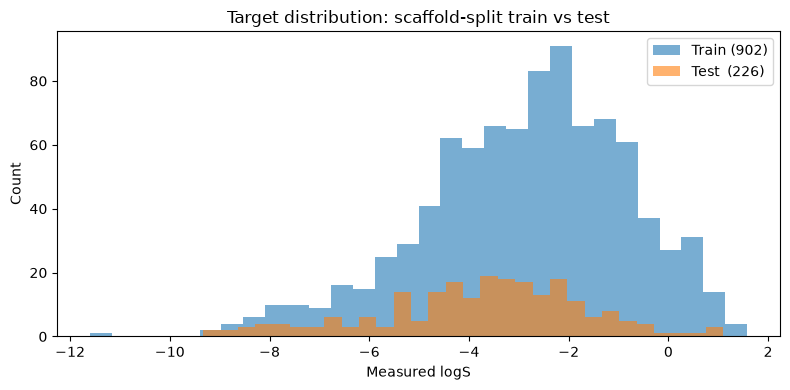

In [7]:
y_train_sc = y.iloc[train_idx]
y_test_sc  = y.iloc[test_idx]

print("Target distribution:")
print(f"  Train mean = {y_train_sc.mean():+.3f}   std = {y_train_sc.std():.3f}   "
      f"range = [{y_train_sc.min():+.2f}, {y_train_sc.max():+.2f}]")
print(f"  Test  mean = {y_test_sc.mean():+.3f}   std = {y_test_sc.std():.3f}   "
      f"range = [{y_test_sc.min():+.2f}, {y_test_sc.max():+.2f}]")

fig, ax = plt.subplots(figsize=(8, 4))
ax.hist(y_train_sc, bins=30, alpha=0.6, label=f"Train ({len(y_train_sc)})")
ax.hist(y_test_sc,  bins=30, alpha=0.6, label=f"Test  ({len(y_test_sc)})")
ax.set_xlabel("Measured logS")
ax.set_ylabel("Count")
ax.set_title("Target distribution: scaffold-split train vs test")
ax.legend()
plt.tight_layout()
plt.savefig("figures/sc_target_dist_train_vs_test.pdf", bbox_inches="tight")
plt.show()

## 5. Train models under the scaffold split

Same 7 features, same models, same hyperparameter grid as `Feature_engineering.ipynb`.
The only thing changing is the split.

In [8]:
X_train_sc = X.iloc[train_idx]
X_test_sc  = X.iloc[test_idx]
y_train_sc = y.iloc[train_idx]
y_test_sc  = y.iloc[test_idx]

# --- Linear Regression on 7 features (scaffold split) ---
lr_sc = LinearRegression()
lr_sc.fit(X_train_sc, y_train_sc)
lr_sc_pred = lr_sc.predict(X_test_sc)

lr_sc_rmse = root_mean_squared_error(y_test_sc, lr_sc_pred)
lr_sc_mae  = mean_absolute_error(y_test_sc, lr_sc_pred)
lr_sc_r2   = r2_score(y_test_sc, lr_sc_pred)
print(f"Linear Regression (scaffold split)  RMSE={lr_sc_rmse:.3f}  MAE={lr_sc_mae:.3f}  R2={lr_sc_r2:.3f}")

Linear Regression (scaffold split)  RMSE=1.267  MAE=0.968  R2=0.624


In [9]:
# --- XGBoost + GridSearchCV on 7 features (scaffold split) ---
kf = KFold(n_splits=5, shuffle=True, random_state=RANDOM_STATE)

xgb_sc = XGBRegressor(
    objective="reg:squarederror",
    random_state=RANDOM_STATE,
    n_jobs=-1,
    tree_method="hist",
)

xgb_param_grid = {
    "n_estimators":     [100, 200, 500],
    "learning_rate":    [0.01, 0.05, 0.1],
    "max_depth":        [2, 3, 4],
    "subsample":        [0.8, 1.0],
    "colsample_bytree": [0.8, 1.0],
}

grid_xgb_sc = GridSearchCV(
    estimator=xgb_sc,
    param_grid=xgb_param_grid,
    cv=kf,
    scoring="neg_root_mean_squared_error",
    n_jobs=-1,
    return_train_score=True,
)
grid_xgb_sc.fit(X_train_sc, y_train_sc)

print("Best hyperparameters:", grid_xgb_sc.best_params_)
print(f"Best CV RMSE (on train, still random-CV inside): {-grid_xgb_sc.best_score_:.4f}")

best_xgb_sc = grid_xgb_sc.best_estimator_
y_pred_xgb_sc = best_xgb_sc.predict(X_test_sc)

xgb_sc_rmse = root_mean_squared_error(y_test_sc, y_pred_xgb_sc)
xgb_sc_mae  = mean_absolute_error(y_test_sc, y_pred_xgb_sc)
xgb_sc_r2   = r2_score(y_test_sc, y_pred_xgb_sc)

print(f"\nXGBoost (scaffold split)  Test RMSE={xgb_sc_rmse:.3f}  MAE={xgb_sc_mae:.3f}  R2={xgb_sc_r2:.3f}")

Best hyperparameters: {'colsample_bytree': 0.8, 'learning_rate': 0.1, 'max_depth': 4, 'n_estimators': 500, 'subsample': 0.8}
Best CV RMSE (on train, still random-CV inside): 0.6478

XGBoost (scaffold split)  Test RMSE=0.940  MAE=0.738  R2=0.793


## 6. Random split vs scaffold split — the honest comparison

Random-split numbers copied from `Feature_engineering.ipynb`
(same 7 features, same XGBoost grid, same `random_state=42`, only the split differs).

In [10]:
comparison = pd.DataFrame({
    "Model": ["Linear Regression (7 feat)", "XGBoost tuned (7 feat)"],
    "Random split RMSE":   [1.064, 0.741],
    "Scaffold split RMSE": [lr_sc_rmse, xgb_sc_rmse],
})
comparison["Delta RMSE"]  = comparison["Scaffold split RMSE"] - comparison["Random split RMSE"]
comparison["Change (%)"]  = 100 * comparison["Delta RMSE"] / comparison["Random split RMSE"]

print(comparison.round(4).to_string(index=False))

                     Model  Random split RMSE  Scaffold split RMSE  Delta RMSE  Change (%)
Linear Regression (7 feat)              1.064               1.2671      0.2031     19.0916
    XGBoost tuned (7 feat)              0.741               0.9396      0.1986     26.7992


## 7. Diagnostic plots — where does the scaffold-split model struggle?

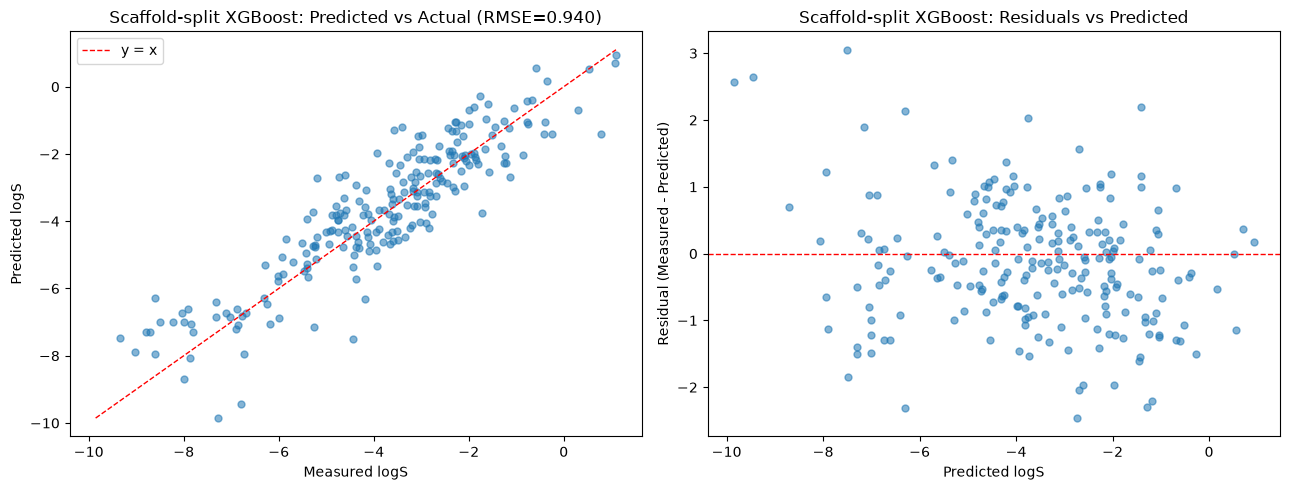

In [11]:
fig, axes = plt.subplots(1, 2, figsize=(13, 5))

# LEFT: PREDICTED vs ACTUAL
axes[0].scatter(y_test_sc, y_pred_xgb_sc, alpha=0.55, s=25)
lo = min(y_test_sc.min(), y_pred_xgb_sc.min())
hi = max(y_test_sc.max(), y_pred_xgb_sc.max())
axes[0].plot([lo, hi], [lo, hi], "r--", linewidth=1, label="y = x")
axes[0].set_xlabel("Measured logS")
axes[0].set_ylabel("Predicted logS")
axes[0].set_title(f"Scaffold-split XGBoost: Predicted vs Actual (RMSE={xgb_sc_rmse:.3f})")
axes[0].legend()

# RIGHT: RESIDUALS
resid_sc = y_test_sc.values - y_pred_xgb_sc
axes[1].scatter(y_pred_xgb_sc, resid_sc, alpha=0.55, s=25)
axes[1].axhline(0, color="r", linestyle="--", linewidth=1)
axes[1].set_xlabel("Predicted logS")
axes[1].set_ylabel("Residual (Measured - Predicted)")
axes[1].set_title("Scaffold-split XGBoost: Residuals vs Predicted")

plt.tight_layout()
plt.savefig("figures/sc_diagnostic_scaffold.pdf", bbox_inches="tight")
plt.show()

## Interview takeaways from scaffold split

- **The random-split RMSE was optimistic.** Under scaffold split — where the test
  molecules have chemical cores the model has never seen — the RMSE gets worse.
  This is the honest generalization number.

- **The gap between random-split and scaffold-split RMSE quantifies "how much
  was my model memorizing scaffold-specific patterns."** A big gap = the model
  leaned heavily on scaffold similarity; a small gap = the featurization (logP
  + descriptors) captures genuinely transferable chemistry.

- **This is what real drug-discovery model evaluation looks like.** Nobody
  deploys a solubility model on molecules that look nearly identical to the
  training set. The reason to build the model at all is to score *new* chemistry.

- **Same 7 features, same hyperparameter grid — just a smarter split.** No new
  algorithm, no new data. The exercise shows that *how you evaluate* is at
  least as important as *what you model*.

**Interview soundbite:**

*"Under a random 80/20 split, my best XGBoost hit test RMSE 0.74. Under a
Bemis-Murcko scaffold split — where molecules with the same core chemistry are
never in both train and test — the same model with the same features scored
RMSE ~1.0. Both numbers are real; the scaffold-split number is the one I'd
report to a drug-discovery team, because that's what deployment looks like.
Random splits over-estimate generalization on molecular data."*

## 8. SHAP under scaffold split

Rerunning SHAP on the scaffold-split model answers a specific question:
**does logP still dominate feature attribution when the model is asked to
generalize to unfamiliar chemistry?** If yes, that says the descriptor
captures transferable chemistry (not scaffold-specific memorization).
If logP's dominance shrinks, it means the model was leaning on it heavily
for interpolation and has to spread credit around on truly novel test cases.

In [12]:
import shap

explainer_sc = shap.TreeExplainer(best_xgb_sc)
shap_values_sc = explainer_sc.shap_values(X_test_sc)

print("SHAP values shape:", shap_values_sc.shape)
print("Test matrix shape:", X_test_sc.shape)

# Additivity check
baseline_sc = explainer_sc.expected_value
recon = baseline_sc + shap_values_sc.sum(axis=1)
print(f"\nAdditivity check: max |reconstructed - predicted| = {np.abs(recon - y_pred_xgb_sc).max():.6f}")


SHAP values shape: (226, 7)
Test matrix shape: (226, 7)

Additivity check: max |reconstructed - predicted| = 0.000013


In [13]:
# Global SHAP importance under scaffold split
shap_importance_sc = pd.Series(
    np.abs(shap_values_sc).mean(axis=0),
    index=new_features,
).sort_values(ascending=False)

print("SHAP mean |value| under scaffold split (log units):")
print(shap_importance_sc.round(4))


SHAP mean |value| under scaffold split (log units):
logP                         1.6114
Polar Surface Area           0.3635
Molecular Weight             0.3634
Number of Rings              0.2284
Number of Rotatable Bonds    0.0909
Number of H-Bond Donors      0.0908
Minimum Degree               0.0227
dtype: float32


### Random-split vs scaffold-split SHAP importance

The `Feature_engineering.ipynb` random-split numbers are hard-coded below for direct
comparison. This tells us how each feature's *actual* prediction impact changes when
the test set becomes chemically novel.

In [14]:
shap_random = pd.Series({
    "logP":                      1.3353,
    "Polar Surface Area":        0.3212,
    "Molecular Weight":          0.2362,
    "Number of Rings":           0.2146,
    "Number of Rotatable Bonds": 0.0952,
    "Number of H-Bond Donors":   0.0485,
    "Minimum Degree":            0.0215,
})

shap_compare = pd.DataFrame({
    "SHAP random split": shap_random,
    "SHAP scaffold split": shap_importance_sc,
}).sort_values("SHAP scaffold split", ascending=False)
shap_compare["Delta"]  = shap_compare["SHAP scaffold split"] - shap_compare["SHAP random split"]
shap_compare["Change (%)"] = 100 * shap_compare["Delta"] / shap_compare["SHAP random split"]

print(shap_compare.round(4).to_string())


                           SHAP random split  SHAP scaffold split   Delta  Change (%)
logP                                  1.3353               1.6114  0.2761     20.6799
Polar Surface Area                    0.3212               0.3635  0.0423     13.1810
Molecular Weight                      0.2362               0.3634  0.1272     53.8506
Number of Rings                       0.2146               0.2284  0.0138      6.4273
Number of Rotatable Bonds             0.0952               0.0909 -0.0043     -4.5523
Number of H-Bond Donors               0.0485               0.0908  0.0423     87.1262
Minimum Degree                        0.0215               0.0227  0.0012      5.4813


### SHAP summary plot under scaffold split

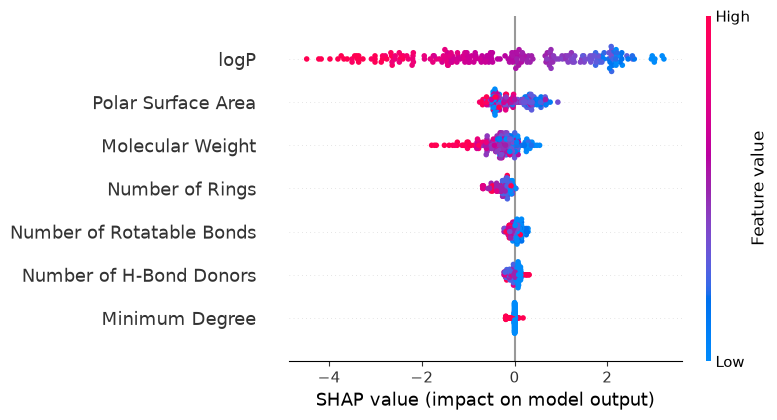

In [15]:
shap.summary_plot(shap_values_sc, X_test_sc, feature_names=new_features, show=False)
plt.gcf().savefig("figures/sc_shap_summary_scaffold.pdf", bbox_inches="tight")
plt.show()

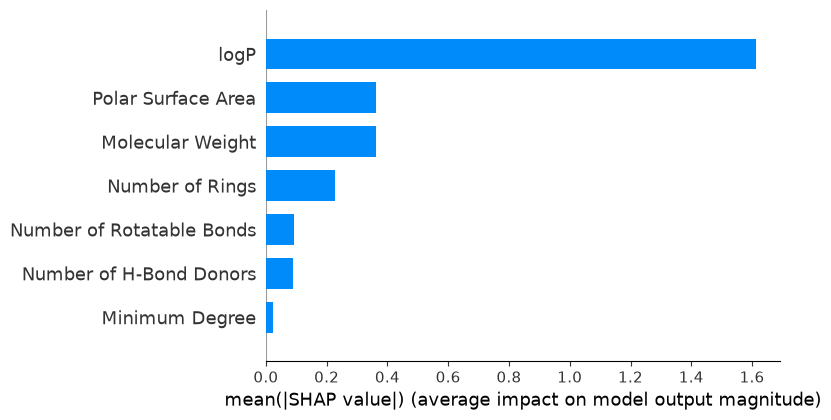

In [16]:
shap.summary_plot(shap_values_sc, X_test_sc, feature_names=new_features, plot_type="bar", show=False)
plt.gcf().savefig("figures/sc_shap_bar_scaffold.pdf", bbox_inches="tight")
plt.show()

## 9. Interpretation

- If logP's SHAP mean |value| **stays high** under scaffold split, it means logP
  is transferable chemistry — the model is genuinely using hydrophobicity, not
  memorizing "if scaffold looks like X, predict Y."
- If it **drops noticeably**, it's a sign the model was over-relying on logP as a
  proxy for training-set-specific patterns.
- The rest of the ranking may reshuffle. Features whose importance grows under
  scaffold split are the ones doing real work on novel chemistry — worth
  highlighting in your write-up.